In [1]:
# General
import numpy as np

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Qiskit Runtime imports
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator

# Plotting routines
import matplotlib.pyplot as plt
import matplotlib.ticker as tck

CHSH quantity S1 = A*(B-b) + a*(B+b), where A and a are the bases of first qubit, and B and b are the bases of the second qubit.  
S1 = +/- 2
|<S1>| =< 2
|<AB>-<Ab>+<aB>|+<ab>| =< 2

S2 = A*(B+b) - a*(B-b) which leads to |<S2>| = |<AB>+<Ab>-<aB>+<ab>| =< 2


In [3]:
service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False, min_num_qubits = 127)
backend.name

qiskit_runtime_service.__init__:WARNING:2026-03-31 10:30:47,542: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-31 10:30:48,452: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-31 10:30:53,549: Using instance: open-instance, plan: open


'ibm_fez'

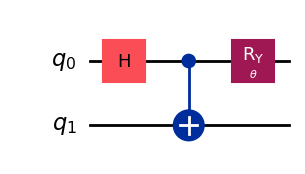

In [ ]:
# create parametrized quantum circuit
theta = Parameter("$\\theta$")
chsh_circuit = QuantumCircuit(2)
chsh_circuit.h(0)
chsh_circuit.cx(0, 1)
chsh_circuit.ry(theta, 0)
chsh_circuit.draw('mpl', idle_wires=False, style='iqp') 

In [6]:
# Create a list of theta values
number_of_phases = 21
phases = np.linspace(0, 2 * np.pi, number_of_phases)
# Phases need to be expressed as list of lists in order to work
individual_phases = [[ph] for ph in phases] 

In [7]:
# Observables
# <CHSH1> = <AB> - <Ab> + <aB> + <ab> -> <ZZ> - <ZX> + <XZ> + <XX>
observable1 = SparsePauliOp.from_list(
    [("ZZ", 1), ("ZX", -1), ("XZ", 1), ("XX", 1)]
                                      )

# # <CHSH1> = <AB> + <Ab> - <aB> + <ab> -> <ZZ> + <ZX> - <XZ> + <XX>
observable2 = SparsePauliOp.from_list(
    [("ZZ", 1), ("ZX", 1), ("XZ", -1), ("XX", 1)]
)

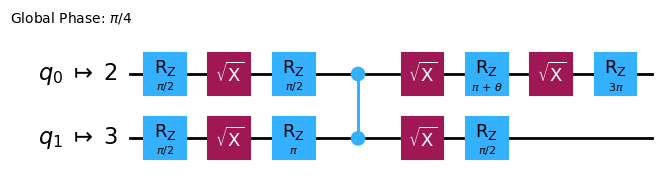

In [8]:
# Optimize
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

chsh_isa_circuit = pm.run(chsh_circuit)
chsh_isa_circuit.draw(output= "mpl", idle_wires= False, style = "iqp")

In [9]:
# Optimize observables

isa_observable1 = observable1.apply_layout(layout=chsh_isa_circuit.layout)
isa_observable2 = observable2.apply_layout(layout=chsh_isa_circuit.layout)

In [10]:
# Execute: To run on a local simulator:
# Use the StatevectorEstimator from qiskit.primitives instead

estimator = Estimator(mode = backend)

pub = (
    chsh_isa_circuit,    # ISA circuit
    [[isa_observable1], [isa_observable2]], # ISA Observables
    individual_phases,  # Parameter values
)

job_result = estimator.run(pubs=[pub]).result()

In [11]:
# Results
chsh1_est = job_result[0].data.evs[0]
chsh2_est = job_result[0].data.evs[1]

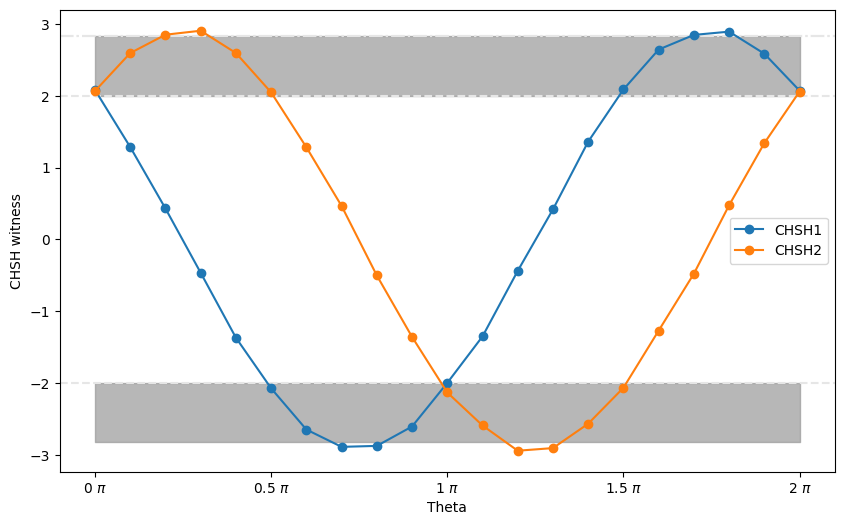

In [13]:
# Post-process
fig, ax = plt.subplots(figsize=(10, 6))

# results from hardware
ax.plot(phases / np.pi, chsh1_est, "o-", label="CHSH1", zorder =3)
ax.plot(phases / np.pi, chsh2_est, "o-", label = "CHSH2", zorder=3)

# Classical bound +-2
ax.axhline(y =2, color = "0.9", linestyle = "--")
ax.axhline(y = -2, color = "0.9", linestyle = "--")

# Quantum bound, +-2\sqrt{2}
ax.axhline(y= np.sqrt(2)*2, color = "0.9", linestyle = "-.")
ax.axhline(y= np.sqrt(2) * 2, color = "0.9", linestyle = "-.")
ax.fill_between(phases / np.pi, 2, 2 * np.sqrt(2), color = "0.6", alpha = 0.7)
ax.fill_between(phases / np.pi, -2, -2 * np.sqrt(2), color = "0.6", alpha = 0.7)

# set x tick labels to the unit of pi
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
ax.xaxis.set_major_locator(tck.MultipleLocator(base = 0.5))

# set labels, and legends
plt.xlabel("Theta")
plt.ylabel("CHSH witness")
plt.legend()
plt.show()